In [43]:
import chromadb
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import umap

from transformers import AutoTokenizer, AutoModel

Embedding z wykorzystaniem modelu `PKOBP/polish-roberta-8k`.

In [3]:
MODEL_NAME = "PKOBP/polish-roberta-8k"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed_embeddings = torch.sum(masked_embeddings, dim=1)
    summed_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed_embeddings / summed_mask

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5793.97it/s]


In [4]:
def embed_texts(texts, max_length=2048, normalize=True, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.to(device)
    model.eval()

    encoded = tokenizer(
        texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    embeddings = mean_pooling(outputs.last_hidden_state, encoded["attention_mask"])

    if normalize:
        embeddings = F.normalize(embeddings, p=2, dim=1)

    return embeddings.cpu()

In [ ]:
documents = [
    "ChromaDB służy do przechowywania embeddingów i wyszukiwania semantycznego.",
    "Model RoBERTa może być używany do reprezentacji tekstu jako wektorów.",
    "Warszawa jest stolicą Polski.",
    "PKOBP polish-roberta-8k dobrze nadaje się do pracy z dłuższymi tekstami po polsku.",
    "Wyszukiwanie semantyczne znajduje treści podobne znaczeniowo, a nie tylko słownikowo.",
    "Embeddingi pozwalają zamieniać tekst na reprezentacje numeryczne w przestrzeni wektorowej.",
    "Modele językowe mogą generować embeddingi dla zdań, dokumentów i zapytań użytkownika.",
    "Wektorowa reprezentacja tekstu ułatwia porównywanie podobieństwa semantycznego między dokumentami.",
    "Retrieval oparty o embeddingi jest często wykorzystywany w systemach RAG.",
    "Bazy wektorowe są używane do szybkiego wyszukiwania podobnych dokumentów w dużych zbiorach.",
    "Chroma może przechowywać dokumenty, metadane i embeddingi w jednej kolekcji.",
    "Metadane w ChromaDB pozwalają filtrować wyniki według źródła, kategorii lub autora.",
    "Kolekcje w ChromaDB działają podobnie do tabel, ale są zoptymalizowane pod retrieval semantyczny.",
    "Zapytania do ChromaDB można wykonywać na podstawie tekstu albo gotowych embeddingów.",
    "Systemy wyszukiwania semantycznego często łączą ChromaDB z modelami embeddingowymi.",
    "RoBERTa jest architekturą transformera wykorzystywaną do zadań rozumienia języka naturalnego.",
    "Model polish-roberta-8k obsługuje dłuższy kontekst niż wiele klasycznych modeli encoderowych.",
    "Tokenizacja tekstu jest pierwszym krokiem przed obliczaniem embeddingów przez model transformera.",
    "Mean pooling nad last_hidden_state to prosty sposób budowania embeddingów dokumentów.",
    "Normalizacja L2 embeddingów bywa stosowana przed wyszukiwaniem podobieństwa kosinusowego.",
    "Warszawa leży nad Wisłą i jest największym miastem w Polsce.",
    "Kraków był dawną stolicą Polski i pozostaje ważnym ośrodkiem kultury.",
    "Gdańsk jest dużym miastem portowym położonym nad Morzem Bałtyckim.",
    "Wrocław słynie z rynku, mostów i licznych wysp na Odrze.",
    "Poznań jest jednym z najstarszych i najważniejszych miast w historii Polski.",
    "Uczenie maszynowe obejmuje metody nadzorowane, nienadzorowane i wzmacniane.",
    "Klasyfikacja tekstu to jedno z podstawowych zastosowań uczenia maszynowego w NLP.",
    "Modele językowe mogą służyć do ekstrakcji informacji, klasyfikacji i wyszukiwania.",
    "Trenowanie modelu wymaga danych, odpowiedniej architektury i procesu optymalizacji.",
    "Ewaluacja modelu retrievalowego często opiera się na metrykach takich jak recall i MRR.",
    "System RAG łączy wyszukiwanie informacji z generowaniem odpowiedzi przez model językowy.",
    "Najpierw retrieval znajduje istotne fragmenty, a potem model generatywny tworzy odpowiedź.",
    "Jakość chunkowania dokumentów ma duży wpływ na skuteczność systemu RAG.",
    "Zbyt duże chunki mogą utrudniać retrieval, a zbyt małe mogą gubić kontekst.",
    "Dobór modelu embeddingowego wpływa na to, jakie dokumenty zostaną uznane za podobne.",
    "Python jest popularnym językiem programowania w data science i machine learningu.",
    "Biblioteka NumPy służy do pracy z tablicami i obliczeniami numerycznymi.",
    "Pandas ułatwia analizę danych tabelarycznych w Pythonie.",
    "Matplotlib pozwala tworzyć wykresy i wizualizacje danych.",
    "UMAP służy do redukcji wymiarów i wizualizacji danych wysokowymiarowych.",
    "Redukcja wymiarów pomaga zobaczyć strukturę danych zapisanych w wielu wymiarach.",
    "UMAP często lepiej zachowuje lokalną strukturę danych niż proste metody liniowe.",
    "Wizualizacja embeddingów w dwóch wymiarach może ujawnić klastry tematyczne dokumentów.",
    "Punkty blisko siebie na wykresie UMAP zwykle odpowiadają podobnym dokumentom.",
    "Interpretacja wykresu 2D powinna być ostrożna, bo redukcja wymiarów upraszcza dane.",
    "Bigos jest tradycyjną potrawą kuchni polskiej przygotowywaną z kapusty i mięsa.",
    "Pierogi ruskie należą do najbardziej znanych dań kuchni polskiej.",
    "Żurek to kwaśna zupa na zakwasie, często podawana z jajkiem i kiełbasą.",
    "Makowiec jest popularnym ciastem przygotowywanym na święta w Polsce.",
    "Kuchnia regionalna w Polsce różni się między Podhalem, Śląskiem i Pomorzem.",
    "Bałtyk jest morzem śródlądowym o stosunkowo niskim zasoleniu.",
    "Tatry są najwyższym pasmem górskim w Polsce.",
    "Mazury są znane z licznych jezior i atrakcji żeglarskich.",
    "Białowieski Park Narodowy chroni jeden z ostatnich lasów pierwotnych Europy.",
    "Polska ma zróżnicowany krajobraz obejmujący góry, niziny, jeziora i wybrzeże.",
    "Algorytmy approximate nearest neighbors przyspieszają wyszukiwanie w bazach wektorowych.",
    "Podobieństwo kosinusowe jest często używane do porównywania embeddingów tekstowych.",
    "Euclidean distance i cosine similarity mogą prowadzić do różnych rankingów wyników.",
    "Indeks wektorowy pozwala szybciej odnajdywać najbliższych sąsiadów w przestrzeni embeddingów.",
    "Skuteczny retrieval zależy zarówno od modelu, jak i od jakości indeksu wektorowego.",
]

In [54]:
embeddings = embed_texts(documents)

In [ ]:
metadatas = [
    {"topic": "vectordb"},
    {"topic": "nlp"},
    {"topic": "geografia"},
    {"topic": "nlp"},
    {"topic": "retrieval"},
    {"topic": "embeddings"},
    {"topic": "embeddings"},
    {"topic": "embeddings"},
    {"topic": "retrieval"},
    {"topic": "vectordb"},
    {"topic": "vectordb"},
    {"topic": "vectordb"},
    {"topic": "vectordb"},
    {"topic": "vectordb"},
    {"topic": "retrieval"},
    {"topic": "nlp"},
    {"topic": "nlp"},
    {"topic": "nlp"},
    {"topic": "embeddings"},
    {"topic": "ml"},
    {"topic": "geografia"},
    {"topic": "geografia"},
    {"topic": "geografia"},
    {"topic": "geografia"},
    {"topic": "geografia"},
    {"topic": "ml"},
    {"topic": "ml"},
    {"topic": "nlp"},
    {"topic": "ml"},
    {"topic": "ml"},
    {"topic": "rag"},
    {"topic": "rag"},
    {"topic": "rag"},
    {"topic": "rag"},
    {"topic": "rag"},
    {"topic": "python"},
    {"topic": "python"},
    {"topic": "python"},
    {"topic": "python"},
    {"topic": "python"},
    {"topic": "umap"},
    {"topic": "umap"},
    {"topic": "umap"},
    {"topic": "umap"},
    {"topic": "umap"},
    {"topic": "kuchnia"},
    {"topic": "kuchnia"},
    {"topic": "kuchnia"},
    {"topic": "kuchnia"},
    {"topic": "kuchnia"},
    {"topic": "przyroda"},
    {"topic": "przyroda"},
    {"topic": "przyroda"},
    {"topic": "przyroda"},
    {"topic": "przyroda"},
    {"topic": "retrieval"},
    {"topic": "retrieval"},
    {"topic": "retrieval"},
    {"topic": "vectordb"},
    {"topic": "retrieval"},
]

In [56]:
ids = [f"doc_{i}" for i in range(len(documents))]

Embeddings.

In [57]:
doc_embeddings = embed_texts(documents)

Chroma.

In [58]:
client = chromadb.PersistentClient(path="./data/chromadb/")
collection = client.get_or_create_collection(name="docs")

Opcjonalnie wyczyść kolekcję, jeśli uruchomisz wielokrotnie.

In [59]:
existing = collection.get()
if existing["ids"]:
    collection.delete(ids=existing["ids"])

collection.add(
    ids=ids,
    documents=documents,
    metadatas=metadatas,
    embeddings=doc_embeddings.tolist(),
)

Zapytanie użytkownika - przygotowanie embeddingu zapytania.

In [60]:
query = "Jakiej bazy użyć do wyszukiwania semantycznego po embeddingach?"
query_embedding = embed_texts([query])

In [61]:
query_embedding.shape

torch.Size([1, 1024])

In [62]:
results = collection.query(
    query_embeddings=query_embedding.tolist(),
    n_results=1,
    include=["documents", "metadatas", "distances"],
)

In [63]:
results

{'ids': [['doc_0']],
 'embeddings': None,
 'documents': [['ChromaDB służy do przechowywania embeddingów i wyszukiwania semantycznego.']],
 'uris': None,
 'included': ['documents', 'metadatas', 'distances'],
 'data': None,
 'metadatas': [[{'topic': 'vectordb'}]],
 'distances': [[0.13773098587989807]]}

In [64]:
embeddings = np.asarray(embeddings, dtype=np.float32)
print(embeddings.shape)

(60, 1024)


In [65]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=2,
    metric="cosine",
    n_jobs=1,
    random_state=42,
)

In [66]:
embeddings_2d = reducer.fit_transform(embeddings)

In [67]:
labels = [metadata["topic"] for metadata in metadatas]

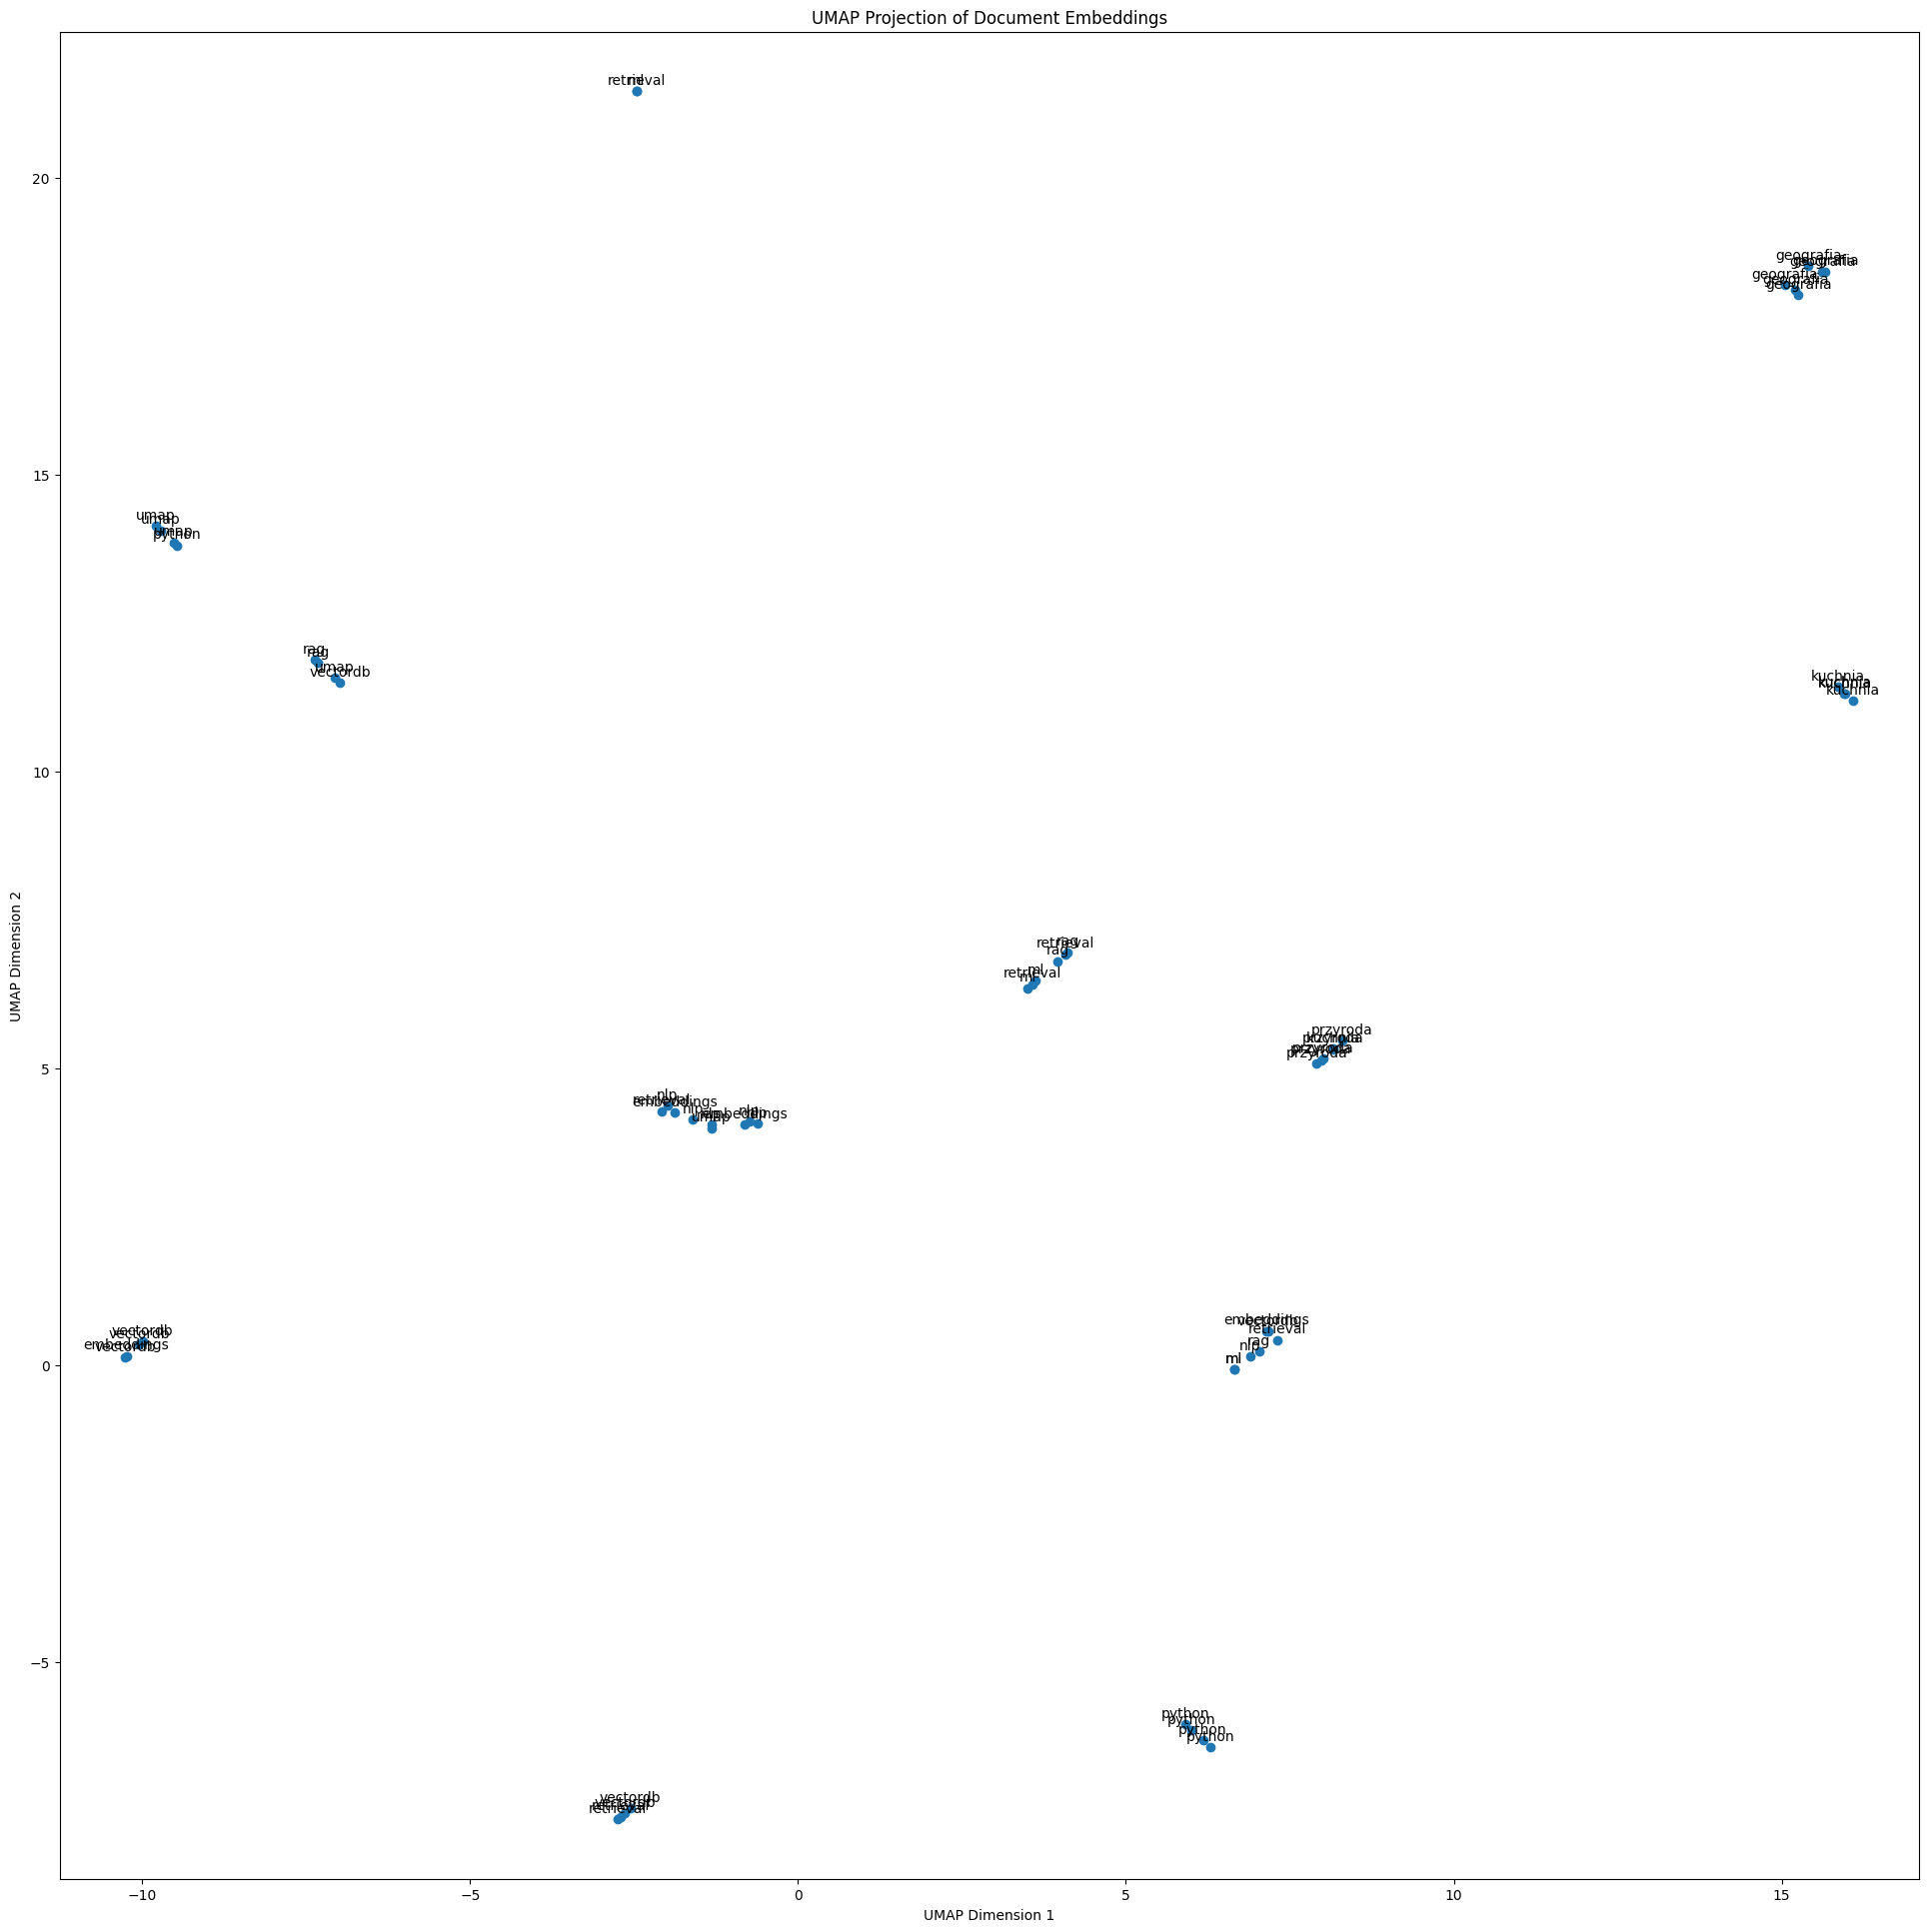

In [ ]:
fig, ax = plt.subplots(figsize=(24, 24))
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, (x, y) in enumerate(embeddings_2d):
    label = labels[i]
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(0, 5), ha="center")
ax.set_xlim(embeddings_2d[:, 0].min() - 1, embeddings_2d[:, 0].max() + 1)
ax.set_ylim(embeddings_2d[:, 1].min() - 1, embeddings_2d[:, 1].max() + 1)
ax.set_title("UMAP Projection of Document Embeddings")
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
plt.show()